# Identifying Outliers in Financial Time Series

In [7]:
#1. Import the required libraries

import pandas as pd 
import yfinance as yf
from datetime import datetime
from dateutil.relativedelta import relativedelta


#2. Download the data and maintain the ajusted close prices only

fecha_inicial = datetime.now()- relativedelta(years=10)
fecha_fin   = datetime.now()

df = yf.download('TMUS', 
                 start=fecha_inicial.strftime('%Y-%m-%d'),
                 end=fecha_fin.strftime('%Y-%m-%d'),
                 auto_adjust=False, progress=False)

df = df.loc[:, ['Adj Close']] 
df.rename(columns={'Adj Close':'adj_close'}, inplace=True)

# 3.Convert the adjusted close prices  to simple returns

df['simple_rtn'] = df.adj_close.pct_change()

#4.Calculate the mean and the standar deviation:

df_rolling = df[['simple_rtn']].rolling(window=21) \
                               .agg(['mean', 'std'])
df_rolling.columns = df_rolling.columns.droplevel()

#5.Merge the means to then original data:

df_outliers = df.join(df_rolling)

#6.Define then function to detect outliers:

def indentify_outliers(row, n_sigmas=3):
    # Ahora que aplanamos las columnas, usamos nombres simples
    x = row['simple_rtn'] 
    mu = row['mean']
    sigma = row['std']
    
    if (x > mu + n_sigmas * sigma) | (x < mu - n_sigmas * sigma):
        return 1
    else:
        return 0



# 7. Ensure the flattening of columns
df_outliers.columns = ['adj_close', 'simple_rtn', 'mean', 'std']

#8.Identify the outliers
df_outliers['outlier'] = df_outliers.apply(indentify_outliers, axis=1)
outliers = df_outliers.loc[df_outliers['outlier'] == 1, ['simple_rtn']]
print(f"{len(outliers)} outliers.")

#9.Graphic the results


25 outliers.


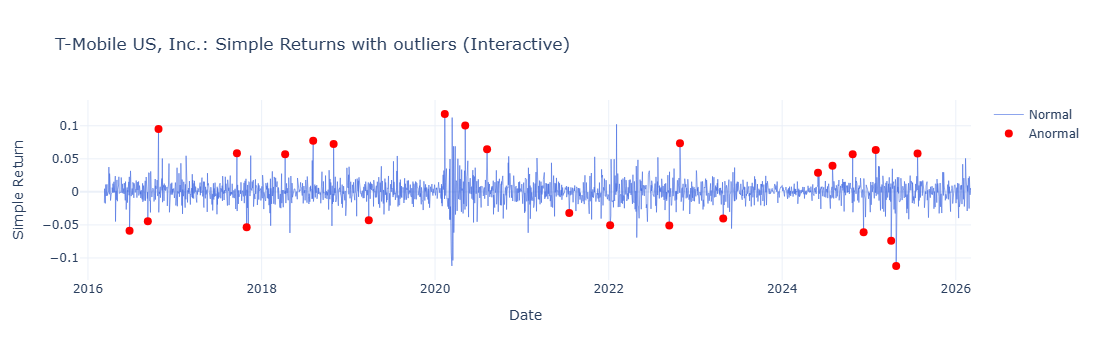

In [8]:
import plotly.graph_objects as go

# 9.1. Create the figure
fig = go.Figure()

# 9.2. Add the normal returns line
fig.add_trace(go.Scatter(
    x=df_outliers.index, 
    y=df_outliers['simple_rtn'],
    mode='lines',
    name='Normal',
    line=dict(color='royalblue', width=1),
    opacity=0.6
))

# 9.3. Add the outliers like red points with customized Tooltip
fig.add_trace(go.Scatter(
    x=outliers.index, 
    y=outliers['simple_rtn'],
    mode='markers',
    name='Anormal',
    marker=dict(color='red', size=8),
    # Configuración del tooltip
    hovertemplate='<b>Date:</b> %{x}<br><b>Return:</b> %{y:.4f}<extra></extra>'
))

# 9.4. customize the design (Layout)
fig.update_layout(
    title="T-Mobile US, Inc.: Simple Returns with outliers (Interactive)",
    xaxis_title="Date",
    yaxis_title="Simple Return",
    template="plotly_white",
    hovermode="x unified" # This shows a unified tooltip for that date
)

fig.show()